In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import f1_score
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True


In [2]:
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES  = 100
EPOCHS       = 50
BATCH_SIZE   = 128
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-4
IMBALANCE_RATIO = 0.01
LAMBDA_RF_WEIGHTED = 1  # Pure weighted RF weight
WARMUP_EPOCHS = 0

print(f"Device: {DEVICE}")


Device: cuda


In [3]:
def make_imbalanced_cifar100(imbalance_ratio=0.01, seed=42):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])

    full_train = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
    test_set   = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

    rng = np.random.default_rng(seed)
    targets = np.array(full_train.targets)
    max_samples = 500

    selected_indices = []
    class_counts = []
    for c in range(NUM_CLASSES):
        n_c = max(int(max_samples * (imbalance_ratio ** (c / (NUM_CLASSES - 1)))), 1)
        class_counts.append(n_c)
        idx_c = np.where(targets == c)[0]
        chosen = rng.choice(idx_c, size=n_c, replace=False)
        selected_indices.extend(chosen.tolist())

    imbalanced_train = Subset(full_train, selected_indices)
    return imbalanced_train, test_set, class_counts

train_set, test_set, class_counts_np = make_imbalanced_cifar100(IMBALANCE_RATIO)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f"Total training samples: {len(train_set)}")
print(f"Total test samples:     {len(test_set)}")

100%|██████████| 169M/169M [00:13<00:00, 12.7MB/s]


Total training samples: 10847
Total test samples:     10000


In [4]:
class_counts = torch.tensor(class_counts_np, dtype=torch.float32, device=DEVICE)
total_samples = class_counts.sum()
class_weights = total_samples / (class_counts * NUM_CLASSES)
class_weights = torch.clamp(class_weights, 1.0, 10.0)

print(f"Class weight stats - min: {class_weights.min():.2f}, max: {class_weights.max():.2f}, mean: {class_weights.mean():.2f}")

Class weight stats - min: 1.00, max: 10.00, mean: 4.03


In [5]:
class ResNet18Penultimate(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        base = torchvision.models.resnet18(weights=None)
        base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()
        self.backbone = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool,
        )
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x, return_features=False):
        h = self.backbone(x)
        h = torch.flatten(h, 1)
        logits = self.fc(h)
        if return_features:
            return logits, h
        return logits

model_exp4 = ResNet18Penultimate(num_classes=NUM_CLASSES).to(DEVICE)
print(f"Trainable parameters: {sum(p.numel() for p in model_exp4.parameters()):,}")

Trainable parameters: 11,220,132


In [6]:
def rf_loss_term_weighted_only(logits, features, fc_weight, class_weights, targets):
    """
    PURE Weighted Relative Flatness Reg.
    Rare classes contribute MORE based on inverse frequency × uncertainty.
    """
    p = torch.softmax(logits, dim=1)
    h_sq = (features ** 2).sum(dim=1)
    p_sq = (p ** 2).sum(dim=1)

    class_conf = p[torch.arange(len(targets)), targets]
    sample_weights = class_weights[targets] * (1.0 - class_conf)

    numerator = (h_sq * (1.0 - p_sq) * sample_weights).mean()
    w_sq = (fc_weight ** 2).sum()
    rf_weighted = numerator / (w_sq + 1e-12)
    return rf_weighted

In [7]:
@torch.no_grad()
def compute_relative_flatness(model, loader, device, max_batches=20):
    model.eval()
    trace_sum = 0.0
    n_samples = 0

    for batch_idx, (x, _) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        x = x.to(device)
        logits, h = model(x, return_features=True)
        p = torch.softmax(logits, dim=1)
        h_sq_norm = (h ** 2).sum(dim=1)
        p_sq_norm = (p ** 2).sum(dim=1)
        trace_sum += (h_sq_norm * (1.0 - p_sq_norm)).sum().item()
        n_samples += x.size(0)

    mean_trace = trace_sum / n_samples
    W = model.fc.weight
    w_norm_sq = (W ** 2).sum().item()
    rf = mean_trace / (w_norm_sq + 1e-12)
    return rf, mean_trace, w_norm_sq

In [8]:
def train_one_epoch_weighted_only(model, loader, criterion, optimizer, device,
                                lambda_rf_weighted, class_weights, apply_rf_reg):
    model.train()
    total_ce_loss, total_rf_reg, correct, total = 0.0, 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits, h = model(x, return_features=True)
        ce_loss = criterion(logits, y)

        if apply_rf_reg:
            reg = rf_loss_term_weighted_only(logits, h, model.fc.weight, class_weights, y)
            loss = ce_loss + lambda_rf_weighted * reg
            total_rf_reg += reg.item() * x.size(0)
        else:
            loss = ce_loss

        loss.backward()
        optimizer.step()

        total_ce_loss += ce_loss.item() * x.size(0)
        correct += logits.argmax(1).eq(y).sum().item()
        total += x.size(0)

    return total_ce_loss / total, total_rf_reg / total, correct / total

In [9]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    class_correct = torch.zeros(NUM_CLASSES)
    class_total = torch.zeros(NUM_CLASSES)
    all_preds, all_targets = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        preds = logits.argmax(1)

        total_loss += loss.item() * x.size(0)
        correct += preds.eq(y).sum().item()
        total += x.size(0)
        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

        for c in range(NUM_CLASSES):
            mask = y.eq(c)
            class_correct[c] += preds[mask].eq(y[mask]).sum().item()
            class_total[c] += mask.sum().item()

    per_class_acc = (class_correct / class_total.clamp(min=1)).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted")

    return total_loss / total, correct / total, per_class_acc, macro_f1, weighted_f1

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_exp4.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [11]:
history = {
    'train_ce_loss': [], 'train_rf_reg': [], 'train_acc': [],
    'val_loss':      [], 'val_acc':      [],
    'rf':            [],
    'macro_f1':      [], 'weighted_f1':  []
}

print("=" * 70)
print(f"Exp 4 — PURE Weighted RF Flatness Reg (λ_wrf={LAMBDA_RF_WEIGHTED}, warmup={WARMUP_EPOCHS})")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):
    apply_rf_reg = (epoch > WARMUP_EPOCHS)

    tr_ce, tr_reg, tr_acc = train_one_epoch_weighted_only(
        model_exp4, train_loader, criterion, optimizer, DEVICE,
        LAMBDA_RF_WEIGHTED, class_weights, apply_rf_reg
    )
    va_loss, va_acc, per_cls, macro_f1, weighted_f1 = evaluate(
        model_exp4, test_loader, criterion, DEVICE
    )
    scheduler.step()

    history['train_ce_loss'].append(tr_ce)
    history['train_rf_reg'].append(tr_reg)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['macro_f1'].append(macro_f1)
    history['weighted_f1'].append(weighted_f1)

    if epoch % 5 == 0 or epoch == 1:
        rf, _, _ = compute_relative_flatness(
            model_exp4, train_loader, DEVICE, max_batches=20
        )
        history['rf'].append((epoch, rf))

        reg_status = f"WRF_reg={tr_reg:.4f}" if apply_rf_reg else "WRF_reg=OFF(warmup)"
        print(
            f"Ep {epoch:3d}/{EPOCHS} | "
            f"CE={tr_ce:.4f} {reg_status} | "
            f"Train acc={tr_acc:.3f} | "
            f"Val acc={va_acc:.3f} | "
            f"Macro-F1={macro_f1:.3f} | "
            f"RF={rf:.4f}"
        )

Exp 4 — PURE Weighted RF Flatness Reg (λ_wrf=1, warmup=0)
Ep   1/50 | CE=4.3020 WRF_reg=0.3995 | Train acc=0.051 | Val acc=0.022 | Macro-F1=0.007 | RF=0.0242
Ep   5/50 | CE=3.5057 WRF_reg=0.0462 | Train acc=0.164 | Val acc=0.059 | Macro-F1=0.022 | RF=0.0368
Ep  10/50 | CE=3.0322 WRF_reg=0.0509 | Train acc=0.253 | Val acc=0.106 | Macro-F1=0.055 | RF=0.0364
Ep  15/50 | CE=2.4433 WRF_reg=0.0526 | Train acc=0.375 | Val acc=0.153 | Macro-F1=0.103 | RF=0.0470
Ep  20/50 | CE=1.8829 WRF_reg=0.0494 | Train acc=0.504 | Val acc=0.212 | Macro-F1=0.154 | RF=0.0439
Ep  25/50 | CE=1.3914 WRF_reg=0.0465 | Train acc=0.623 | Val acc=0.256 | Macro-F1=0.198 | RF=0.0425
Ep  30/50 | CE=0.8954 WRF_reg=0.0433 | Train acc=0.748 | Val acc=0.297 | Macro-F1=0.245 | RF=0.0409
Ep  35/50 | CE=0.4346 WRF_reg=0.0338 | Train acc=0.884 | Val acc=0.338 | Macro-F1=0.288 | RF=0.0305
Ep  40/50 | CE=0.1577 WRF_reg=0.0197 | Train acc=0.969 | Val acc=0.362 | Macro-F1=0.317 | RF=0.0164
Ep  45/50 | CE=0.0802 WRF_reg=0.0121 | Tra

In [12]:
_, final_val_acc, final_per_cls, final_macro_f1, final_weighted_f1 = evaluate(
    model_exp4, test_loader, criterion, DEVICE
)
final_rf, _, _ = compute_relative_flatness(
    model_exp4, train_loader, DEVICE, max_batches=None
)

print("\n── Exp 4 Final Results ────────────────────────────────────")
print(f"Overall test accuracy : {final_val_acc:.4f}")
print(f"Macro F1 score        : {final_macro_f1:.4f}")
print(f"Weighted F1 score     : {final_weighted_f1:.4f}")
print(f"Relative Flatness (RF): {final_rf:.6f}")

print("\nPer-class test accuracy:")
for c, acc in enumerate(final_per_cls):
    n_train = class_counts_np[c]
    bar = "█" * int(acc * 20)
    print(f"  Class {c:2d} (n={n_train:4d}): {acc:.3f}  {bar}")


── Exp 4 Final Results ────────────────────────────────────
Overall test accuracy : 0.3724
Macro F1 score        : 0.3354
Weighted F1 score     : 0.3354
Relative Flatness (RF): 0.010535

Per-class test accuracy:
  Class  0 (n= 500): 0.930  ██████████████████
  Class  1 (n= 477): 0.840  ████████████████
  Class  2 (n= 455): 0.640  ████████████
  Class  3 (n= 434): 0.600  ████████████
  Class  4 (n= 415): 0.670  █████████████
  Class  5 (n= 396): 0.730  ██████████████
  Class  6 (n= 378): 0.750  ███████████████
  Class  7 (n= 361): 0.710  ██████████████
  Class  8 (n= 344): 0.790  ███████████████
  Class  9 (n= 328): 0.770  ███████████████
  Class 10 (n= 314): 0.510  ██████████
  Class 11 (n= 299): 0.510  ██████████
  Class 12 (n= 286): 0.790  ███████████████
  Class 13 (n= 273): 0.760  ███████████████
  Class 14 (n= 260): 0.480  █████████
  Class 15 (n= 248): 0.690  █████████████
  Class 16 (n= 237): 0.730  ██████████████
  Class 17 (n= 226): 0.810  ████████████████
  Class 18 (n= 216)

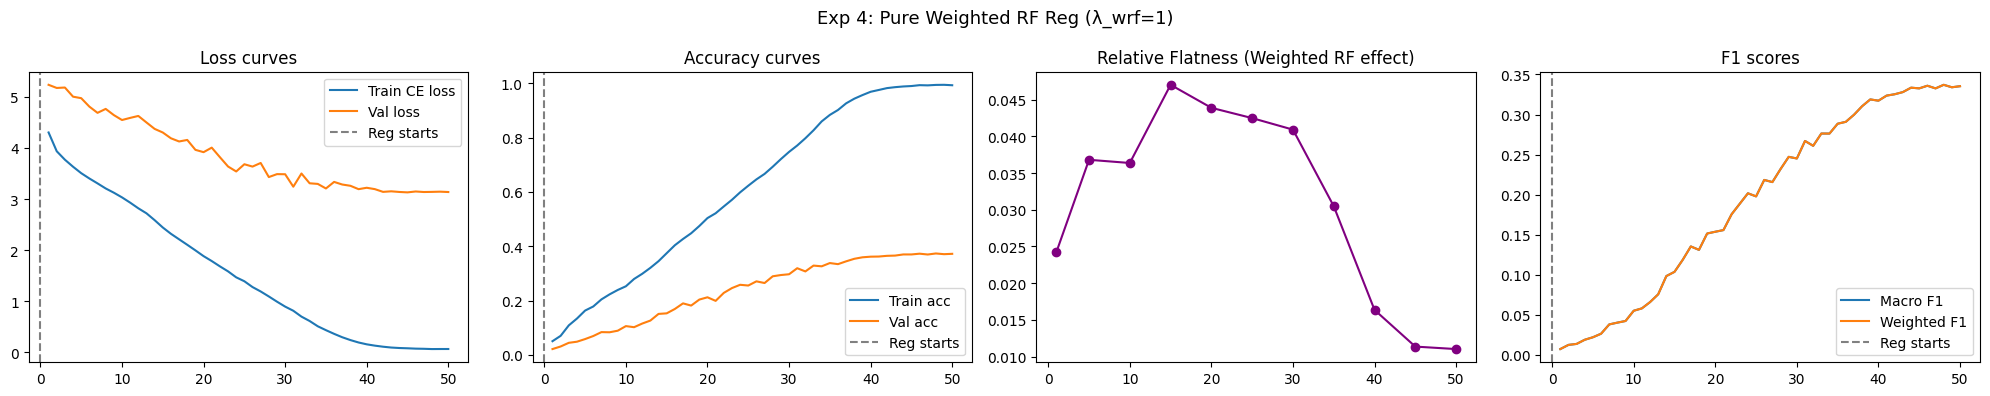

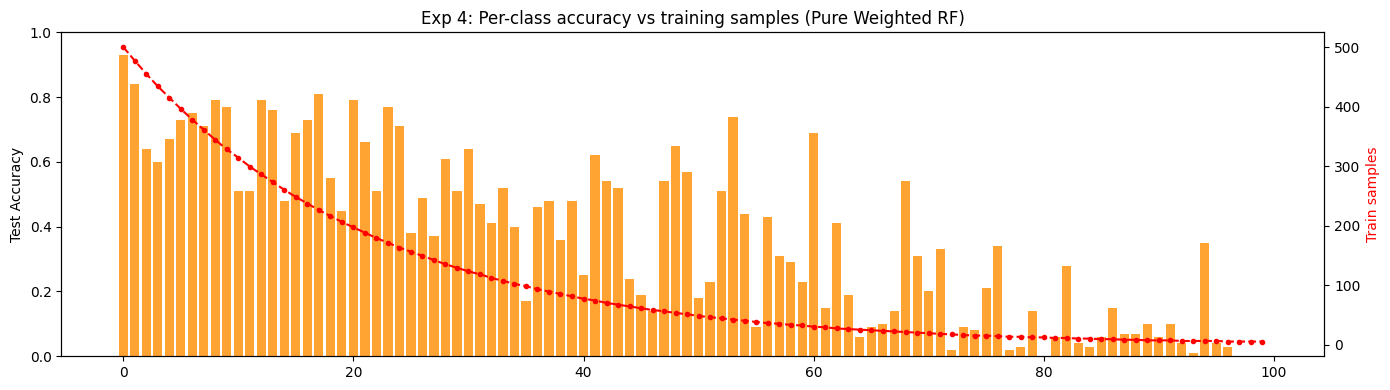

In [13]:
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(f"Exp 4: Pure Weighted RF Reg (λ_wrf={LAMBDA_RF_WEIGHTED})", fontsize=13)

axes[0].plot(epochs_x, history['train_ce_loss'], label='Train CE loss')
axes[0].plot(epochs_x, history['val_loss'], label='Val loss')
axes[0].axvline(WARMUP_EPOCHS, color='gray', linestyle='--', label='Reg starts')
axes[0].set_title("Loss curves"); axes[0].legend()

axes[1].plot(epochs_x, history['train_acc'], label='Train acc')
axes[1].plot(epochs_x, history['val_acc'], label='Val acc')
axes[1].axvline(WARMUP_EPOCHS, color='gray', linestyle='--', label='Reg starts')
axes[1].set_title("Accuracy curves"); axes[1].legend()

rf_epochs, rf_vals = zip(*history['rf'])
axes[2].plot(rf_epochs, rf_vals, marker='o', color='purple')
axes[2].set_title("Relative Flatness (Weighted RF effect)")

axes[3].plot(epochs_x, history['macro_f1'], label='Macro F1')
axes[3].plot(epochs_x, history['weighted_f1'], label='Weighted F1')
axes[3].axvline(WARMUP_EPOCHS, color='gray', linestyle='--', label='Reg starts')
axes[3].set_title("F1 scores"); axes[3].legend()

plt.tight_layout()
plt.savefig("exp4_pure_weighted_rf.png", dpi=150)
plt.show()

fig2, ax = plt.subplots(figsize=(14, 4))
x = np.arange(NUM_CLASSES)
ax.bar(x, final_per_cls, color='darkorange', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(x, class_counts_np, 'r--o', markersize=3)
ax2.set_ylabel("Train samples", color='red')
ax.set_ylabel("Test Accuracy"); ax.set_ylim(0, 1)
ax.set_title(f"Exp 4: Per-class accuracy vs training samples (Pure Weighted RF)")
plt.tight_layout()
plt.savefig("exp4_perclass.png", dpi=150)
plt.show()